In [8]:
import pandas as pd
import numpy as np

In [10]:
df = pd.read_csv("/your_file_path")

In [12]:
print(df)

        Unnamed: 0  user id test group  converted  total ads most ads day  \
0                0  1069124         ad      False        130       Monday   
1                1  1119715         ad      False         93      Tuesday   
2                2  1144181         ad      False         21      Tuesday   
3                3  1435133         ad      False        355      Tuesday   
4                4  1015700         ad      False        276       Friday   
...            ...      ...        ...        ...        ...          ...   
588096      588096  1278437         ad      False          1      Tuesday   
588097      588097  1327975         ad      False          1      Tuesday   
588098      588098  1038442         ad      False          3      Tuesday   
588099      588099  1496395         ad      False          1      Tuesday   
588100      588100  1237779         ad      False          1      Tuesday   

        most ads hour  
0                  20  
1                  22  
2  

In [14]:
df.head()

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   Unnamed: 0     588101 non-null  int64 
 1   user id        588101 non-null  int64 
 2   test group     588101 non-null  object
 3   converted      588101 non-null  bool  
 4   total ads      588101 non-null  int64 
 5   most ads day   588101 non-null  object
 6   most ads hour  588101 non-null  int64 
dtypes: bool(1), int64(4), object(2)
memory usage: 27.5+ MB


In [18]:
df.columns

Index(['Unnamed: 0', 'user id', 'test group', 'converted', 'total ads',
       'most ads day', 'most ads hour'],
      dtype='object')

In [20]:
#Select COUNT(*) AS total_rows from ab_test
#Counting Total number of rows 
total_rows = len(df)
print("Total Rows", total_rows)

Total Rows 588101


In [22]:
#Count Users in Each Group  
''' SELECT test_group, COUNT(*) AS users
FROM ab_test 
GROUP BY test_group'''

group_counts = df["test group"].value_counts()
print(group_counts)

test group
ad     564577
psa     23524
Name: count, dtype: int64


In [24]:
group_summary = df["test group"].value_counts().reset_index()

group_summary.columns = ["test_group", "users"]

group_summary["pct_of_total"] = round(group_summary["users"]*100/total_rows, 2)

print(group_summary)

  test_group   users  pct_of_total
0         ad  564577          96.0
1        psa   23524           4.0


### Step 2 Calculate Conversion Rates By Test Group

In [27]:
conversion_summary = (df.groupby("test group").agg(total_users = ("test group", "count"), converted_users=("converted", "sum")).reset_index())

In [29]:

conversion_summary["conversion_rate_pct"] = round(
    conversion_summary["converted_users"]*100/conversion_summary["total_users"],
    2
)

print(conversion_summary)

  test group  total_users  converted_users  conversion_rate_pct
0         ad       564577            14423                 2.55
1        psa        23524              420                 1.79


### Step 3A Look At Ad Exposure By Test Group

In [32]:
ad_exposure_summary = (
    df.groupby("test group")
    .agg(
        avg_ads_seen=("total ads", "mean"),
        min_ads = ("total ads", "min"),
        max_ads=("total ads", "max"),
        median_Ads=("total ads", "median")
    )
    .reset_index()
)

ad_exposure_summary["avg_ads_seen"] = round(
    ad_exposure_summary["avg_ads_seen"],1
)

print(ad_exposure_summary)

  test group  avg_ads_seen  min_ads  max_ads  median_Ads
0         ad          24.8        1     2065        13.0
1        psa          24.8        1      907        12.0


### Step 3B Create Ad-Volume Buckets 

In [35]:
df["ads bucket"]=np.select(
    [
        df["total ads"].between(1,10),
        df["total ads"].between(11,50),
        df["total ads"].between(51,100)
    ],
    [
        "1-10 ads",
        "11-50 ads",
        "51-100 ads"
    ],
    default="100 + ads"
)

### Step 3C Conversion Rate By Ad-Volume Bucket For Ad Group Only

In [38]:
ad_bucket_summary = (
    df[df["test group"] == "ad"]
    .groupby("ads bucket")
    .agg(
        users = ("ads bucket", "count"),
        converted_users = ("converted", "sum")
    ) 
    .reset_index()
)
ad_bucket_summary["conversion_rate_pct"] = round(
    ad_bucket_summary["converted_users"]*100/ad_bucket_summary["users"], 
    2
)
print(ad_bucket_summary)

   ads bucket   users  converted_users  conversion_rate_pct
0    1-10 ads  249499              813                 0.33
1   100 + ads   22054             3779                17.14
2   11-50 ads  248875             4696                 1.89
3  51-100 ads   44149             5135                11.63


### Step 4A Find Which Day Drives The Most Conversions == Best Day To Show Ads


In [41]:
day_summary = (
    df[df["test group"] == "ad"]
    .groupby("most ads day")
    .agg(
        users=("most ads day", "count"),
        conversions=("converted","sum")
    )
    .reset_index()
)

day_summary["conversion_rate_pct"] = round(
    day_summary["conversions"]*100/day_summary["users"],
    2
)
day_summart = day_summary.sort_values(
    by = "conversion_rate_pct",
    ascending=False
)
print(day_summary)

  most ads day  users  conversions  conversion_rate_pct
0       Friday  88805         1995                 2.25
1       Monday  83571         2778                 3.32
2     Saturday  78802         1679                 2.13
3       Sunday  82332         2027                 2.46
4     Thursday  79077         1711                 2.16
5      Tuesday  74572         2270                 3.04
6    Wednesday  77418         1963                 2.54


### Step 4B Best Hour To Show Ads

In [44]:
# Finding which hour drives the most conversions

hour_summary = (
    df[df["test group"] == "ad"]
    .groupby("most ads hour")
    .agg(
        users=("most ads hour", "count"),
        conversions=("converted", "sum")
    )
    .reset_index()
)

hour_summary["conversion_rate_pct"] = round(
    hour_summary["conversions"] * 100 / hour_summary["users"],
    2
)

hour_summary = hour_summary.sort_values(
    by="conversion_rate_pct",
    ascending=False
).head(5)

print(hour_summary)

    most ads hour  users  conversions  conversion_rate_pct
16             16  35963         1111                 3.09
20             20  27846          843                 3.03
15             15  42855         1279                 2.98
21             21  28895          843                 2.92
14             14  43779         1251                 2.86


### Step 5: Statistical significance test

In [47]:
from scipy.stats import chi2_contingency


# Create contingency table
contingency = pd.crosstab(
    df["test group"],
    df["converted"]
)

print(contingency)

# Run chi-square test
chi2, p, dof, expected = chi2_contingency(contingency)

print(f"Chi-square: {chi2:.2f}")
print(f"p-value: {p:.2e}")
print(f"Degrees of freedom: {dof}")
print("Expected values:")
print(expected)

converted    False  True 
test group               
ad          550154  14423
psa          23104    420
Chi-square: 54.01
p-value: 2.00e-13
Degrees of freedom: 1
Expected values:
[[550327.71899045  14249.28100955]
 [ 22930.28100955    593.71899045]]


### Step 6: Summarised Findings

In [49]:


final_summary = (
    df.groupby("test group")
    .agg(
        total_users=("test group", "count"),
        conversions=("converted", "sum"),
        avg_ads_seen=("total ads", "mean")
    )
    .reset_index()
)

final_summary["conversion_rate_pct"] = round(
    final_summary["conversions"] * 100 / final_summary["total_users"],
    2
)

final_summary["avg_ads_seen"] = round(
    final_summary["avg_ads_seen"],
    1
)

final_summary = final_summary[
    [
        "test group",
        "total_users",
        "conversions",
        "conversion_rate_pct",
        "avg_ads_seen"
    ]
]

print(final_summary)

  test group  total_users  conversions  conversion_rate_pct  avg_ads_seen
0         ad       564577        14423                 2.55          24.8
1        psa        23524          420                 1.79          24.8


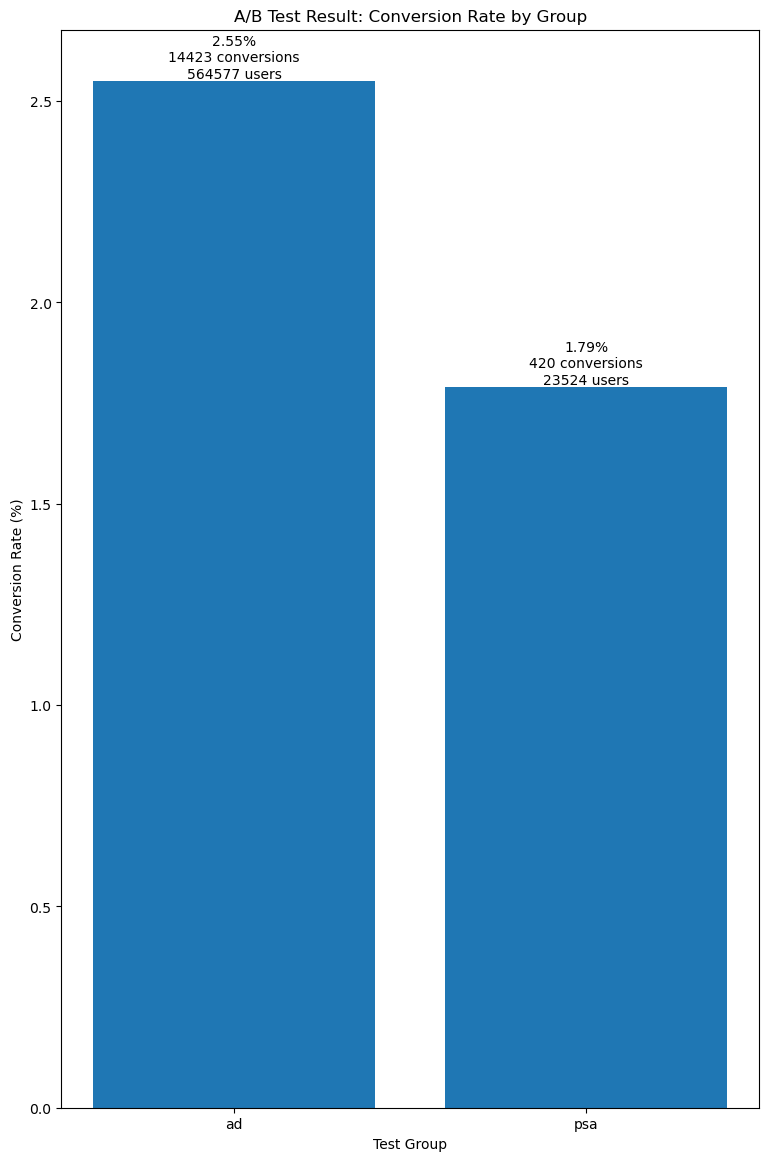

In [56]:
import matplotlib.pyplot as plt

# Step 7: Visualize final A/B test result

plt.figure(figsize=(9, 14))

bars = plt.bar(
    final_summary["test group"],
    final_summary["conversion_rate_pct"]
)

plt.title("A/B Test Result: Conversion Rate by Group")
plt.xlabel("Test Group")
plt.ylabel("Conversion Rate (%)")

# Add labels above each bar
for bar, rate, users, conversions in zip(
    bars,
    final_summary["conversion_rate_pct"],
    final_summary["total_users"],
    final_summary["conversions"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{rate}%\n{conversions} conversions\n{users} users",
        ha="center",
        va="bottom"
    )

plt.show()